# Updatining Predictions for Unlabeled Trials

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import torch
import deeplabcut
import DLCsupport as dlcs
import deeplabcut as dlc
import matplotlib.pyplot as plt

import glob
import xrommtools as xt
import re
import shutil

from PIL import Image
from PostAnalysis_review import find_darkest_pixel, collect_images


Loading DLC 3.0.0rc13...
DLC loaded in light mode; you cannot use any GUI (labeling, relabeling and standalone GUI)


In [14]:
src_trial = Path(
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial8\active_updates\dino"
)

models = src_trial / "ModelsToTune"
models.mkdir(exist_ok=True)
# 1) Ensure we have a real DLC project config.yaml to write labeled-data into
# Replace dummy_video with any existing video file you already use for project init.
combined_config = dlcs.create_combined_project_if_missing(
    task="Canari",
    experimenter="Tyler_Finetune",
    combined_project_root=models,
    dummy_video=Path(
        r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial8\Cam1.avi"
    ),
)

# edit the config.yaml to add our 2D points CSV as a scorer with appropriate bodyparts and skeleton info
bodyparts_apply_df = dlcs.apply_bird_bodyparts_to_configs(
        {"DavidBowie": [combined_config]},
        strict=True,
    )

# 2) Build a clean trial folder for xma_to_dlc

clean_trial = src_trial / "ModelTraining"
clean_trial.mkdir(parents=True, exist_ok=True)

# Copy camera folders
for cam_folder in ["Cam1", "Cam2"]:
    src = src_trial / cam_folder
    dst = clean_trial / cam_folder
    if dst.exists():
        shutil.rmtree(dst)
    shutil.copytree(src, dst)

# Pick truth CSV and keep only coordinate columns
truth_csv = src_trial / "data/corrections_autosave.csv" 
df = pd.read_csv(truth_csv)

coord_cols = [c for c in df.columns if re.search(r"_cam[12]_[XY]$", c)]
clean_df = df[coord_cols]

# Name contains 2Dpoints so xrommtools picks it first
clean_points_csv = clean_trial / "UpdatedLabels-2Dpoints.csv"
clean_df.to_csv(clean_points_csv, index=False)

# 3) Build dataset from cleaned trial
dlcs.build_combined_dataset(
    combined_config=combined_config,      # real config.yaml path
    data_path=clean_trial,                # folder containing csv + Cam1 + Cam2
    dataset_name="For_Test_20_Eval17_Dino_n400_s125",
    experimenter="Tyler",
    nframes=30,
    frame_selection_seed=42,
)

Created "C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial8\active_updates\dino\ModelsToTune\Canari-Tyler_Finetune-2026-06-12\videos"
Created "C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial8\active_updates\dino\ModelsToTune\Canari-Tyler_Finetune-2026-06-12\labeled-data"
Created "C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial8\active_updates\dino\ModelsToTune\Canari-Tyler_Finetune-2026-06-12\training-datasets"
Created "C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial8\active_updates\dino\ModelsToTune\Canari-Tyler_Finetune-2026-06-12\dlc-models"
Attempting to create a symbolic link of the video ...
Symlink creation impossible (exFat architecture?): copying the video instead.
C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingDat

In [15]:
import time
snapshot_path = (
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\Model519\n400_T17\Canari-Tyler-2026-05-22\dlc-models-pytorch\iteration-0\CanariMay22-trainset95shuffle1\train\snapshot-100.pt"
)
t0 = time.perf_counter()
dlcs.create_and_train(
    config_path=combined_config,
    epochs=100,
    snapshot_path=snapshot_path
)
elapsed = time.perf_counter() - t0
print(elapsed)

Updated scorer in C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial8\active_updates\dino\ModelsToTune\Canari-Tyler_Finetune-2026-06-12\config.yaml from 'Tyler_Finetune' to 'Tyler'


C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial8\active_updates\dino\ModelsToTune\Canari-Tyler_Finetune-2026-06-12\labeled-data\Cam1\CollectedData_Tyler.h5  not found (perhaps not annotated).
Annotation data was not found by splitting video paths (from config['video_sets']). An alternative route is taken...
The following folders were found: ['C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\ProcessingData\\DavidBowie\\Trial8\\active_updates\\dino\\ModelsToTune\\Canari-Tyler_Finetune-2026-06-12\\labeled-data\\Cam1', 'C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\ProcessingData\\DavidBowie\\Trial8\\active_updates\\dino\\ModelsToTune\\Canari-Tyler_Finetune-2026-06-12\\labeled-data\\For_Test_20_Eval17_Dino_n400_s125']
C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial8\active_updates\dino\ModelsToTune\Canari-Tyle

Training with configuration:
data:
  bbox_margin: 20
  colormode: RGB
  inference:
    normalize_images: True
  train:
    affine:
      p: 0.5
      rotation: 30
      scaling: [0.5, 1.25]
      translation: 0
    crop_sampling:
      width: 448
      height: 448
      max_shift: 0.1
      method: hybrid
    gaussian_noise: 12.75
    motion_blur: True
    normalize_images: True
device: auto
inference:
  multithreading:
    enabled: True
    queue_length: 4
    timeout: 30.0
  compile:
    enabled: False
    backend: inductor
  autocast:
    enabled: False
metadata:
  project_path: C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial8\active_updates\dino\ModelsToTune\Canari-Tyler_Finetune-2026-06-12
  pose_config_path: C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial8\active_updates\dino\ModelsToTune\Canari-Tyler_Finetune-2026-06-12\dlc-models-pytorch\iteration-0\CanariJun12-tr

FileNotFoundError: No snapshots found under pattern: C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial8\active_updates\dino\ModelsToTune\Canari-Tyler_Finetune-2026-06-12\dlc-models-pytorch\iteration-0\*\train\snapshots\snapshot-*.pt

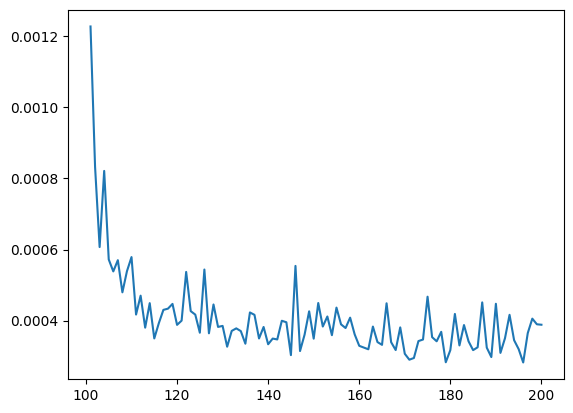

In [16]:
# plot learning stats
learning_stats = pd.read_csv(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial8\active_updates\dino\ModelsToTune\Canari-Tyler_Finetune-2026-06-12\dlc-models-pytorch\iteration-0\CanariJun12-trainset95shuffle1\train\learning_stats.csv")
learning_stats.head()
plt.plot(learning_stats["step"], learning_stats["losses/train.total_loss"], label="train_loss")

In [19]:
dlc.analyze_videos(
    combined_config,
    [str(Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial8\Cam1.avi")), str(Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial8\Cam2.avi"))],
    save_as_csv=True,
    destfolder=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial8\active_updates\dino",
    batchsize=16
)

Analyzing videos with C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial8\active_updates\dino\ModelsToTune\Canari-Tyler_Finetune-2026-06-12\dlc-models-pytorch\iteration-0\CanariJun12-trainset95shuffle1\train\snapshot-200.pt
Using scorer: DLC_Resnet50_CanariJun12shuffle1_snapshot_200
Starting to analyze C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial8\Cam2.avi
Video metadata: 
  Overall # of frames:    6001
  Duration of video [s]:  12.00
  fps:                    500.0
  resolution:             w=768, h=768

Running pose prediction with batch size 16


100%|██████████| 6001/6001 [02:50<00:00, 35.23it/s]


Saving results in C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial8\active_updates\dino\Cam2DLC_Resnet50_CanariJun12shuffle1_snapshot_200.h5 and C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial8\active_updates\dino\Cam2DLC_Resnet50_CanariJun12shuffle1_snapshot_200_full.pickle
Starting to analyze C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial8\Cam1.avi
Video metadata: 
  Overall # of frames:    6001
  Duration of video [s]:  12.00
  fps:                    500.0
  resolution:             w=768, h=768

Running pose prediction with batch size 16


100%|██████████| 6001/6001 [02:50<00:00, 35.26it/s]


Saving results in C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial8\active_updates\dino\Cam1DLC_Resnet50_CanariJun12shuffle1_snapshot_200.h5 and C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial8\active_updates\dino\Cam1DLC_Resnet50_CanariJun12shuffle1_snapshot_200_full.pickle
The videos are analyzed. Now your research can truly start!
You can create labeled videos with 'create_labeled_video'.
If the tracking is not satisfactory for some videos, consider expanding the training set. You can use the function 'extract_outlier_frames' to extract a few representative outlier frames.



'DLC_Resnet50_CanariJun12shuffle1_snapshot_200'

In [21]:
xt.dlc_to_xma(
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial8\active_updates\dino\Cam1DLC_Resnet50_CanariJun12shuffle1_snapshot_200.csv", 
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial8\active_updates\dino\Cam1DLC_Resnet50_CanariJun12shuffle1_snapshot_200.csv", 
    "ModelUpdate", 
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial8")

### Snapping to the nearest Darkstar!
Across the imagestack/predictions

In [ ]:

def snap_combined_predictions_to_dark_pixels(
    pred_csv,
    cam1_dir,
    cam2_dir,
    out_csv=None,
    window_size=5,
):
    """Snap each predicted keypoint to the nearest dark pixel in the matching frame image."""
    pred_csv = Path(pred_csv)
    cam1_dir = Path(cam1_dir)
    cam2_dir = Path(cam2_dir)

    df = pd.read_csv(pred_csv)
    out = df.copy()

    images_by_cam = {
        "cam1": collect_images(cam1_dir),
        "cam2": collect_images(cam2_dir),
    }

    # Parse columns like bodypart_cam1_X / bodypart_cam2_Y
    col_pattern = re.compile(r"(?P<bodypart>.+)_cam(?P<cam>[12])_(?P<coord>[XY])$")
    col_map = {}
    bodyparts = set()
    for col in out.columns:
        match = col_pattern.match(str(col))
        if match is None:
            continue
        bp = str(match.group("bodypart"))
        cam = f"cam{match.group('cam')}"
        coord = str(match.group("coord")).upper()
        col_map[(bp, cam, coord)] = col
        bodyparts.add(bp)

    if not bodyparts:
        raise ValueError(
            "No prediction columns found in combined format (expected bodypart_cam1_X style columns)."
        )

    bodyparts = sorted(bodyparts)

    n_frames = len(out)
    print(f"Snapping {len(bodyparts)} bodyparts across {n_frames} frames...")

    for frame_pos in range(n_frames):
        if frame_pos % 100 == 0:
            print(f"  frame {frame_pos}/{n_frames - 1}")

        for cam in ("cam1", "cam2"):
            images = images_by_cam[cam]
            if not (0 <= frame_pos < len(images)):
                continue

            with Image.open(images[frame_pos]) as image_file:
                gray_img = np.asarray(image_file.convert("L"))

            occupied_pixels = set()

            for bp in bodyparts:
                xcol = col_map.get((bp, cam, "X"))
                ycol = col_map.get((bp, cam, "Y"))
                if xcol is None or ycol is None:
                    continue

                x_val = pd.to_numeric(out.at[frame_pos, xcol], errors="coerce")
                y_val = pd.to_numeric(out.at[frame_pos, ycol], errors="coerce")
                if not (np.isfinite(x_val) and np.isfinite(y_val)):
                    continue

                rr, cc = find_darkest_pixel(
                    gray_img,
                    row=float(y_val),
                    col=float(x_val),
                    occupied=occupied_pixels,
                    window_size=int(window_size),
                )

                out.at[frame_pos, xcol] = float(cc)
                out.at[frame_pos, ycol] = float(rr)

    if out_csv is None:
        out_csv = pred_csv.with_name(f"{pred_csv.stem}_snapped_dark.csv")
    else:
        out_csv = Path(out_csv)

    out.to_csv(out_csv, index=False)
    print(f"Saved snapped predictions: {out_csv}")
    return out_csv, out


# snapped_csv, snapped_df = snap_combined_predictions_to_dark_pixels(
#     pred_csv=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial8\ModelUpdate-Predicted2DPoints.csv",
#     cam1_dir=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial8\Cam1",
#     cam2_dir=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial8\Cam2",
#     # out_csv=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial8\ModelUpdate-Predicted2DPoints-snapped-dark.csv",
#     window_size=4,
# )

# snapped_df.head()

Snapping 21 bodyparts across 6001 frames...
  frame 0/6000
  frame 100/6000
  frame 200/6000
  frame 300/6000
  frame 400/6000
  frame 500/6000
  frame 600/6000
  frame 700/6000
  frame 800/6000
  frame 900/6000
  frame 1000/6000
  frame 1100/6000
  frame 1200/6000
  frame 1300/6000
  frame 1400/6000
  frame 1500/6000
  frame 1600/6000
  frame 1700/6000
  frame 1800/6000
  frame 1900/6000
  frame 2000/6000
  frame 2100/6000
  frame 2200/6000
  frame 2300/6000
  frame 2400/6000
  frame 2500/6000
  frame 2600/6000
  frame 2700/6000
  frame 2800/6000
  frame 2900/6000
  frame 3000/6000
  frame 3100/6000
  frame 3200/6000
  frame 3300/6000
  frame 3400/6000
  frame 3500/6000
  frame 3600/6000
  frame 3700/6000
  frame 3800/6000
  frame 3900/6000
  frame 4000/6000
  frame 4100/6000
  frame 4200/6000
  frame 4300/6000
  frame 4400/6000
  frame 4500/6000
  frame 4600/6000
  frame 4700/6000
  frame 4800/6000
  frame 4900/6000
  frame 5000/6000
  frame 5100/6000
  frame 5200/6000
  frame 5300/6

,Cranium_Left_Anterior_cam1_X,Cranium_Left_Anterior_cam1_Y,Cranium_Left_Anterior_cam2_X,Cranium_Left_Anterior_cam2_Y,Cranium_Left_Middle_cam1_X,Cranium_Left_Middle_cam1_Y,Cranium_Left_Middle_cam2_X,Cranium_Left_Middle_cam2_Y,Cranium_Right_Middle_cam1_X,Cranium_Right_Middle_cam1_Y,...,Pelvis_Right_Superior_cam2_X,Pelvis_Right_Superior_cam2_Y,Pelvis_Left_Superior_cam1_X,Pelvis_Left_Superior_cam1_Y,Pelvis_Left_Superior_cam2_X,Pelvis_Left_Superior_cam2_Y,Pelvis_Left_Inferior_cam1_X,Pelvis_Left_Inferior_cam1_Y,Pelvis_Left_Inferior_cam2_X,Pelvis_Left_Inferior_cam2_Y
0,333.0,214.0,410.0,235.0,341.0,208.0,447.0,231.0,311.0,221.0,...,573.0,479.0,307.0,427.0,602.0,480.0,309.0,430.0,605.0,485.0
1,334.0,212.0,410.0,234.0,340.0,208.0,447.0,231.0,311.0,221.0,...,573.0,479.0,306.0,427.0,602.0,480.0,309.0,430.0,603.0,481.0
2,335.0,212.0,411.0,234.0,339.0,208.0,449.0,230.0,308.0,219.0,...,573.0,479.0,307.0,428.0,601.0,481.0,307.0,427.0,604.0,483.0
3,335.0,212.0,411.0,234.0,339.0,208.0,449.0,230.0,307.0,220.0,...,573.0,479.0,306.0,427.0,604.0,483.0,306.0,428.0,604.0,482.0
4,336.0,212.0,413.0,233.0,338.0,208.0,451.0,230.0,307.0,220.0,...,574.0,481.0,306.0,427.0,602.0,479.0,306.0,428.0,605.0,484.0


In [25]:
snapped_csv, snapped_df = snap_combined_predictions_to_dark_pixels(
    pred_csv=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial8\PredictedPoints\ModelUpdate-Predicted2DPoints.csv",
    cam1_dir=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial8\Cam1",
    cam2_dir=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial8\Cam2",
    #out_csv=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\active_updates_trial8\ModelUpdate-Predicted2DPoints-snapped-dark.csv",
    window_size=3,
)

snapped_df.head()

Snapping 21 bodyparts across 6001 frames...
  frame 0/6000
  frame 100/6000
  frame 200/6000
  frame 300/6000
  frame 400/6000
  frame 500/6000
  frame 600/6000
  frame 700/6000
  frame 800/6000
  frame 900/6000
  frame 1000/6000
  frame 1100/6000
  frame 1200/6000
  frame 1300/6000
  frame 1400/6000
  frame 1500/6000
  frame 1600/6000
  frame 1700/6000
  frame 1800/6000
  frame 1900/6000
  frame 2000/6000
  frame 2100/6000
  frame 2200/6000
  frame 2300/6000
  frame 2400/6000
  frame 2500/6000
  frame 2600/6000
  frame 2700/6000
  frame 2800/6000
  frame 2900/6000
  frame 3000/6000
  frame 3100/6000
  frame 3200/6000
  frame 3300/6000
  frame 3400/6000
  frame 3500/6000
  frame 3600/6000
  frame 3700/6000
  frame 3800/6000
  frame 3900/6000
  frame 4000/6000
  frame 4100/6000
  frame 4200/6000
  frame 4300/6000
  frame 4400/6000
  frame 4500/6000
  frame 4600/6000
  frame 4700/6000
  frame 4800/6000
  frame 4900/6000
  frame 5000/6000
  frame 5100/6000
  frame 5200/6000
  frame 5300/6

,Cranium_Left_Anterior_cam1_X,Cranium_Left_Anterior_cam1_Y,Cranium_Left_Anterior_cam2_X,Cranium_Left_Anterior_cam2_Y,Cranium_Left_Middle_cam1_X,Cranium_Left_Middle_cam1_Y,Cranium_Left_Middle_cam2_X,Cranium_Left_Middle_cam2_Y,Cranium_Right_Middle_cam1_X,Cranium_Right_Middle_cam1_Y,...,Pelvis_Right_Superior_cam2_X,Pelvis_Right_Superior_cam2_Y,Pelvis_Left_Superior_cam1_X,Pelvis_Left_Superior_cam1_Y,Pelvis_Left_Superior_cam2_X,Pelvis_Left_Superior_cam2_Y,Pelvis_Left_Inferior_cam1_X,Pelvis_Left_Inferior_cam1_Y,Pelvis_Left_Inferior_cam2_X,Pelvis_Left_Inferior_cam2_Y
0,334.0,213.0,333.0,213.0,341.0,208.0,340.0,208.0,306.0,219.0,...,274.0,432.0,306.0,428.0,305.0,428.0,309.0,430.0,309.0,431.0
1,334.0,212.0,335.0,212.0,340.0,207.0,340.0,207.0,306.0,219.0,...,276.0,431.0,306.0,427.0,305.0,428.0,309.0,430.0,307.0,430.0
2,335.0,212.0,335.0,212.0,339.0,208.0,338.0,207.0,306.0,219.0,...,275.0,431.0,306.0,427.0,305.0,428.0,308.0,431.0,308.0,430.0
3,335.0,212.0,335.0,213.0,339.0,208.0,337.0,208.0,307.0,220.0,...,276.0,430.0,306.0,427.0,304.0,426.0,308.0,430.0,308.0,429.0
4,336.0,212.0,336.0,210.0,338.0,207.0,337.0,207.0,307.0,220.0,...,274.0,432.0,306.0,428.0,305.0,428.0,308.0,431.0,306.0,430.0
